# Kolokvijum 1 - Marko Gordić - IN 37-2023

- Potrebno je istrenirati model višestruke linearne regresije nad podacima
  iz trening skupa (data/train.csv) koji prediktuje ostvareni broj poena na
  završnom ispitu (**FinalExamScore**).

- **Opis prisutnih kolona:**
  - **DailyStudyHours** – prosečan broj sati koje student provede učenji na dnevnom nivou
  - **ClassAttendance** – procenat prisustva na časovima
  - **PreviousYearGPA** – prosečna ocena od prethodne godine
  - **SleepDuration** – prosečan broj sati sna dnevno
  - **PartTimeWorkHours** – prosečan broj sati rada van fakulteta nedeljno
  - **SocialMediaUsage** – prosečan broj sati provedenih na socijalnim mrežama dnevno
  - **CampusFacilityRating** – prosečna ocena uslova na kampusu
  - **PreferredStudyTemperature** – preferirana temperature tokom učenja u celzijusima
  - **FinalExamScore** – ostvareni poeni na završnom ispitu


In [1]:
import pandas as pd
import warnings
import statsmodels.api as sm
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sb
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import normal_ad
from sklearn.metrics import r2_score
from statsmodels.tools import add_constant

warnings.filterwarnings("ignore")

def check_for_missing_values(df):
    missing_values = df.isna().sum()
    non_zero_missing = missing_values[missing_values != 0]
    non_zero_missing_percentage = (non_zero_missing / len(df)) * 100
    return pd.DataFrame({
        'N missing': non_zero_missing,
        '% missing': non_zero_missing_percentage
    })

def check_missing_for_rows(df):
    """
    Funkcija koja mi radi analizu redova i govori mi koliko podataka u isto vreme fali u nekom redu.
    Na ovaj nacin mogu da znam koji su mi zagadjeni redovi odnosno redovi gde mi fali mnogo podataka, pa
    njih mogu samo odma da izmacim jer fali mnogo i ukoliko ih bilo kako dopunim, bice previse vestacki.
     """
    row_missing = df.isna().sum(axis=1)
    counts = row_missing.value_counts().sort_index()

    return pd.DataFrame({
        "N rows": counts,
        "% rows": counts / len(df) * 100
    })


df_test = pd.read_csv("./data/test.csv", sep=',')
df_train = pd.read_csv("./data/train.csv", sep=',')

#print(check_for_missing_values(df_train))
#print(check_missing_for_rows(df_train))

Sada smo završili sa učotavanjem naših podataka. Prvo što radimo je provera da li imamo vrednosti koje nedostaju u našim podacima. Nakon provere utvrdili smo da u sklopu podataka za treniranje fali određen deo podataka.

| Feature                     | N missing | % missing |
|----------------------------|-----------|-----------|
| SleepDuration              | 127       | 12.7      |
| SocialMediaUsage           | 293       | 29.3      |
| CampusFacilityRating       | 193       | 19.3      |
| PreferredStudyTemperature  | 234       | 23.4      |

Takodje, radim i analizu toga koliko podataka fali u svakom od redova, pa opet procentualno, ovo mi znaci jer mogu da vidim redove gde mnogo toga fali, ti redovi su mi poprilicno beskorisni s obzirom da ukoliko dopunim podatke, red ce biti previse vestacki napravljen, sto mi nije cilj.

| # missing columns | N rows | % rows |
|-------------------|--------|--------|
| 0                 | 385    | 38.5   |
| 1                 | 417    | 41.7   |
| 2                 | 167    | 16.7   |
| 3                 | 28     | 2.8    |
| 4                 | 3      | 0.3    |

PS. GPT mi je konvertovao oba ispisa u markdown tabelu da ne gubim vreme na to a izgleda lepse. I u nastavku cu ovakve tabelice tako konvertovati.

Odlucujem se da izbacim sve redove u kojima fale 3 i 4 promenljive odmah. Dok cu ove gde fale 2 ostaviti.

In [2]:
def drop_rows_with_too_many_missing(df, max_missing=2):
    row_missing = df.isna().sum(axis=1)
    df_clean = df[row_missing <= max_missing].copy()
    return df_clean

df_train = drop_rows_with_too_many_missing(df_train)

Sada sam obrisao redove za koje smatram da su evidentno losi po moj model. Sada ukoliko proverim isto, dobijam malo bolje rezultate.

| Column                     | N missing | % missing |
|----------------------------|-----------|-----------|
| SleepDuration              | 110       | 11.35     |
| SocialMediaUsage           | 264       | 27.24     |
| CampusFacilityRating       | 167       | 17.23     |
| PreferredStudyTemperature  | 210       | 21.67     |

Sada cemo dopuniti podatke koji fale. Odlucujem se za popunjavanje srednjom vrednoscu, ali postoje i alternativni metodi.

In [3]:
def fillna_mean(df, col_name):
    df_copy = df.copy()
    col_mean = df_copy[col_name].mean()
    df_copy[col_name] = df[col_name].fillna(col_mean)
    return df_copy

df_train_filled = fillna_mean(df_train, 'SocialMediaUsage')
df_train_filled = fillna_mean(df_train_filled, 'SleepDuration')
df_train_filled = fillna_mean(df_train_filled, 'CampusFacilityRating')
df_train_filled = fillna_mean(df_train_filled, 'PreferredStudyTemperature')

Dolazimo do matrice korelacije. Pre nego sto predjemo nastavimo, moramo da zadovoljimo to da ne postoji savrsena kolinearnost izmedju 2 ili vise prom. Takodje, ukoliko uocimo jaku kolinearnost, potrebno je dodatno analizirati jer uklanjanjem iste potencijalno mozemo poboljsati model.

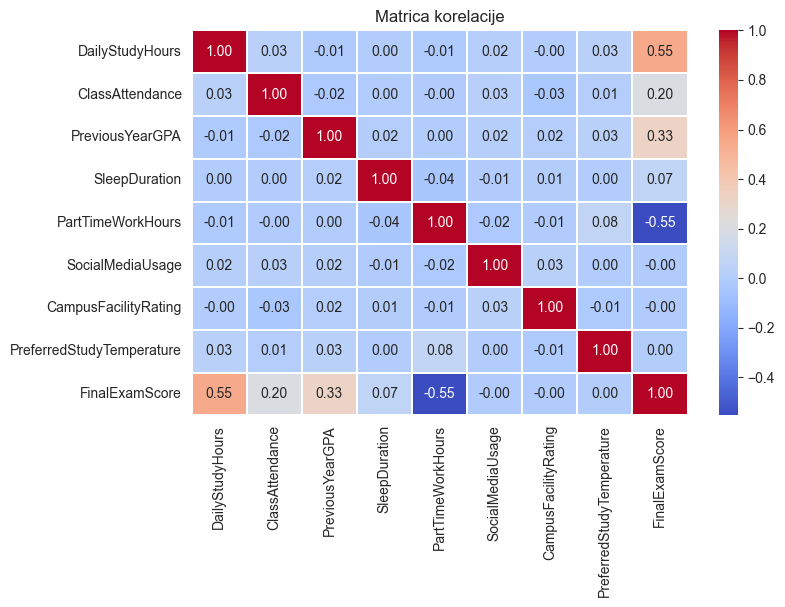

In [4]:
matplotlib.rcParams['figure.figsize'] = (8, 5)

correlation_matrix = df_train_filled.corr()

sb.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.1)
plt.title('Matrica korelacije')
plt.show()

Iz matrice korelacije vidimo da ne postoje dve nezavisne promenljive sa jakom ili saversenom korelacijom, pa nema potrebe da u ovom trenutku ista uklanjamo.

Iz matricemo mozemo izvesti nekoliko zakljucaka, predpostavicu da su u pitanju studenti:
1. Sto su studenti imali veci GPA prosle godine, postoji indikator da ce njihova ocena biti veca
2. Veca prisutnost na predavanjima ukacuje na vecu ocenu
3. Broj casova provedenih uceci ukazuje na vecu ocenu, sto je vrlo logicno
4. Takodje, sto veci broj casova rada part time pored faksa ukazuje na smanjenje ocene

Sada smo zavrsili obradu redova koji imaju podatke koji nedostaju. Posto su vrednosti dopunjene srednjom vrednoscu, moze doci do vestackog povecanja t vrednosti pa je rezultate t testa potrebno analizirati sa dodatnim oprezom.

Sada cemo da kreiramo model visestruke linearne regresije. Za kolone uzimam sve osim FinalExamScore koju i zelimo da predvidjamo.

In [5]:
col_names = ['DailyStudyHours', 'ClassAttendance', 'PreviousYearGPA', 'SleepDuration', 'PartTimeWorkHours', 'SocialMediaUsage', 'CampusFacilityRating', 'PreferredStudyTemperature']

def get_fitted_model(x, y):
    x_with_const = sm.add_constant(x)
    model = sm.OLS(y, x_with_const).fit()
    return model

x_train = df_train_filled[col_names]
y_train = df_train_filled['FinalExamScore']

model_train = get_fitted_model(x_train, y_train)

In [6]:
alpha = 0.05

for param in model_train.params.index:
    if param == "const":
        continue

    p_value = model_train.pvalues[param]
    t_value = model_train.tvalues[param]

    if p_value < alpha:
        print(
            f"Linearnost : Test t-test daje vrednost t = {t_value}, p = {p_value} -> "
            f"{param} je u linearnoj zavisnosti sa y u prisustvu drugih promenljivih. Ispunjen je dovoljan uslov linearnosti (p < {alpha})"
        )
    else:
        print(
            f"Linearnost: Test t-test daje vrednost t = {t_value}, p = {p_value} -> "
            f"{param} nema veliki uticaj na y u prisustvu drugih promenljivih. Nije ispunjen dovoljan uslov linearnosti (p >= {alpha}), pa ne mozemo garantovati da je veza linearna."
        )

Linearnost : Test t-test daje vrednost t = 33.46412609799766, p = 2.3976916736556917e-163 -> DailyStudyHours je u linearnoj zavisnosti sa y u prisustvu drugih promenljivih. Ispunjen je dovoljan uslov linearnosti (p < 0.05)
Linearnost : Test t-test daje vrednost t = 11.72789545847745, p = 8.83763143145826e-30 -> ClassAttendance je u linearnoj zavisnosti sa y u prisustvu drugih promenljivih. Ispunjen je dovoljan uslov linearnosti (p < 0.05)
Linearnost : Test t-test daje vrednost t = 20.825823147595194, p = 8.910053162469761e-80 -> PreviousYearGPA je u linearnoj zavisnosti sa y u prisustvu drugih promenljivih. Ispunjen je dovoljan uslov linearnosti (p < 0.05)
Linearnost : Test t-test daje vrednost t = 2.4513116736300002, p = 0.01441100820696814 -> SleepDuration je u linearnoj zavisnosti sa y u prisustvu drugih promenljivih. Ispunjen je dovoljan uslov linearnosti (p < 0.05)
Linearnost : Test t-test daje vrednost t = -34.0081026457267, p = 5.369609604476722e-167 -> PartTimeWorkHours je u li

T test nam je pokazao da dve promenljive imaju visoku p-vrednost. CampusFacilityRating i PreferredStudyTemperature imaju visoke p-vrednosti. T test nam zapravo govori koliko nam neka promenljiva doprinosi samom modelu. Ove dve velike p vrenosti nam zapravo govore da ove dve promenljive verovatno ne doprinose modelu i da bi njihovom eliminacijom poboljsali model.

Sada cu da uradim brzu proveru modela sa i bez te dve promenljive, t test mi je dao dovoljan razlog da ovo uradim.

In [7]:
# https://www.statsmodels.org/dev/generated/statsmodels.regression.linear_model.OLSResults.rsquared_adj.html
def adjusted_r2_statsmodels(rsquared, nobs, df_resid, has_const=True):
    if has_const:
        return 1 - ((nobs - 1) / df_resid) * (1 - rsquared)
    else:
        return 1 - (nobs / df_resid) * (1 - rsquared)

col_names_improved = ['DailyStudyHours', 'ClassAttendance', 'PreviousYearGPA', 'SleepDuration', 'PartTimeWorkHours', 'SocialMediaUsage']

df_train_filled_improved = df_train.drop(
    columns=['CampusFacilityRating', 'PreferredStudyTemperature']
)
df_train_filled_improved = fillna_mean(df_train_filled_improved, 'SocialMediaUsage')
df_train_filled_improved = fillna_mean(df_train_filled_improved, 'SleepDuration')

x_train_improved = df_train_filled_improved[col_names_improved]
y_train_improved = df_train_filled_improved['FinalExamScore']

model_train_improved = get_fitted_model(x_train_improved, y_train_improved)

Prvo sam kreirao jos jedan model koji ovog puta nema ove dve kolone. Sada cemo da ih uporedimo. Test cemo raditi nad testnim podacima.

In [8]:
x_test = df_test[col_names]
x_test_improved = df_test[col_names_improved]
y_test = df_test['FinalExamScore']

x_with_const_test = sm.add_constant(x_test)
x_with_const_test_improved = sm.add_constant(x_test_improved)

y_pred = model_train.predict(x_with_const_test)
y_pred_improved = model_train_improved.predict(x_with_const_test_improved)

r2_1 = r2_score(y_test, y_pred)
r2_2 = r2_score(y_test, y_pred_improved)

nobs = len(y_test)
df_resid_1 = nobs - len(model_train.params)
df_resid_2 = nobs - len(model_train_improved.params)

r2_adj_1 = adjusted_r2_statsmodels(r2_1, nobs, df_resid_1, has_const=True)
r2_adj_2 = adjusted_r2_statsmodels(r2_2, nobs, df_resid_2, has_const=True)

Dobijamo da je Adj R2 za obican model 0.739641948633591, a za model sa izbacenim promenljivim 0.7429178184885668. Ovo mi govori da sam doneo ispravnu odluku i poboljsao model. Sada cemo odraditi F test.

In [9]:
alpha = 0.05

if model_train_improved.f_pvalue <= alpha:
    print(f"Postojanje linearne veze (bar jedan β≠0): Test F-test daje vrednost p = {model_train_improved.f_pvalue} -> "
          f"Pretpostavka važi, zbog p <= {alpha}.")
else:
    print(f"Postojanje linearne veze (bar jedan β≠0): Test F-test daje vrednost p = {model_train_improved.f_pvalue} -> "
          f"Pretpostavka ne važi, zbog p > {alpha}.")

Postojanje linearne veze (bar jedan β≠0): Test F-test daje vrednost p = 1.052690980411101e-285 -> Pretpostavka važi, zbog p <= 0.05.


Nastavljamo sa LINE testovima.

Sada prelazimo na ostale LINE testove. U nastavku ce biti uradjeni:
1. Nezavisnost gresaka -> Durbin Watson
2. Normalnost gresaka -> LOWESS i Anderson Darling
3. Jednaka varijansa -> Goldfeld Quandt

## 1. Nezavisnost gresaka -> Durbin Watson

Prvo moramo izracunati rezuidule pa tek onda mozemo odraditi test.

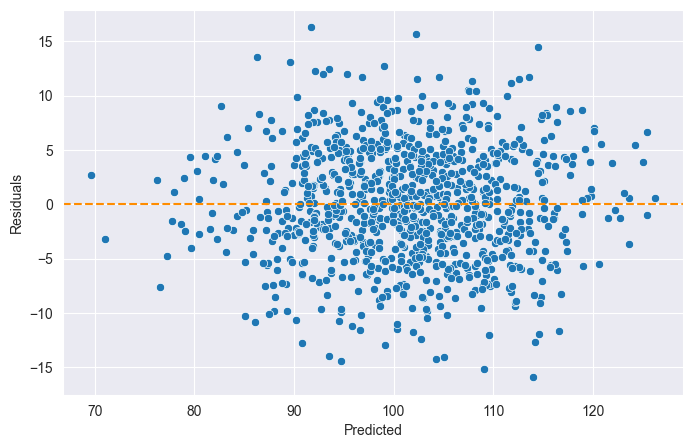

Autokorelacija reziduala: Test Durbin-Watson daje vrednost 1.5515286604739784 -> Pretpostavka važi, jer ne postoji autokorelacija


In [10]:
def calculate_residuals(model, features, labels):
    y_pred = model.predict(features)
    df_results = pd.DataFrame({'Actual': labels, 'Predicted': y_pred})
    df_results['Residuals'] = df_results['Actual'] - df_results['Predicted']
    return df_results

df_results = calculate_residuals(model_train_improved, sm.add_constant(x_train_improved), y_train_improved)

durbinWatson = durbin_watson(df_results['Residuals'])

sb.scatterplot(x='Predicted', y='Residuals', data=df_results)
plt.axhline(y=0, color='darkorange', linestyle='--')
plt.show()

if durbinWatson < 1.5:
    print(
        f"Autokorelacija reziduala: Test Durbin-Watson daje vrednost {durbinWatson} -> "
        f"Pretpostavka ne važi, zbog prisustva pozitivne autokorelacije"
    )
elif durbinWatson > 2:
    print(
        f"Autokorelacija reziduala: Test Durbin-Watson daje vrednost {durbinWatson} -> "
        f"Pretpostavka ne važi, zbog prisustva negativne autokorelacije"
    )
else:
    print(
        f"Autokorelacija reziduala: Test Durbin-Watson daje vrednost {durbinWatson} -> "
        f"Pretpostavka važi, jer ne postoji autokorelacija"
    )


Nezavisnost gresaka smo testirali odgovarajucim testom, ali sam prikazao i grafik. Ukoliko grafik ima sablon koji mozemo predpostaviti, predpostavka je narusena. Statisticki test dokazuje da sablon ne postoji.

## 2. Normalnost gresaka -> LOWESS i Anderson Darling

### 2.1 Srednja vrednost 0 za greske

Reziduali ne odstupaju mnogo od nule, linija ima minimalne oscilacije na pocetku i kraju, ali je to sve sitno pa pretpostavka da su greške distribuirane oko 0 važi

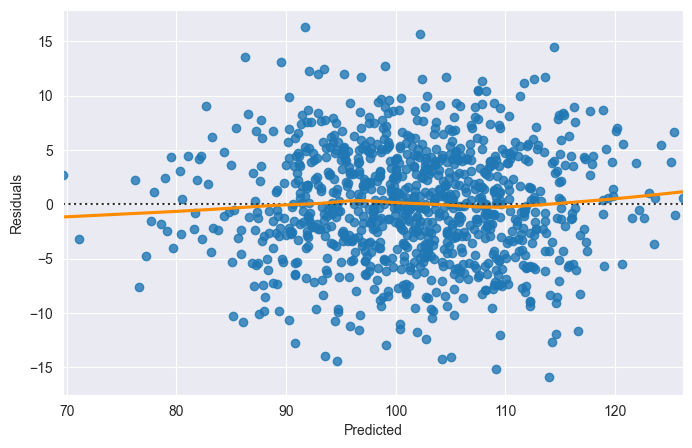

In [11]:
sb.residplot(data=df_results, x='Predicted', y='Residuals', lowess=True,  line_kws={'color': 'darkorange'})
plt.show()

### 2.2 Greske su normalno distribuirane

Sada cemo koristiti Anderson-Darling test.

Normalnost reziduala: Test Anderson-Darling daje vrednost p = 0.5422 -> Pretpostavka važi (p >= 0.05)


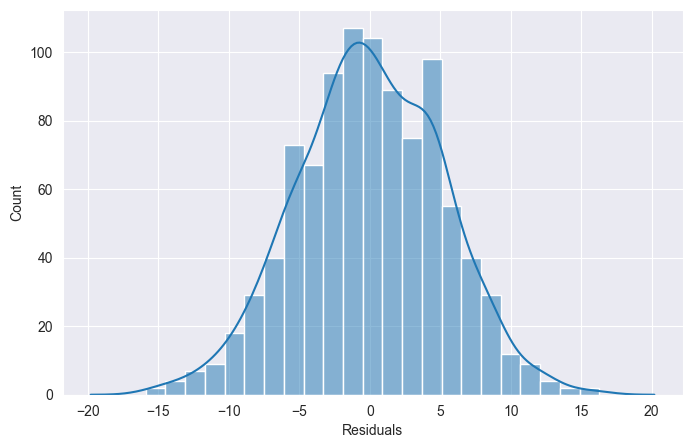

In [12]:
p_value_thresh = 0.05
p_value = normal_ad(df_results['Residuals'])[1]

sb.histplot(df_results['Residuals'], kde=True, kde_kws=dict(cut=3));

if p_value >= p_value_thresh:
    print(
        f"Normalnost reziduala: Test Anderson-Darling daje vrednost p = {p_value:.4f} -> "
        f"Pretpostavka važi (p >= {p_value_thresh})"
    )
else:
    print(
        f"Normalnost reziduala: Test Anderson-Darling daje vrednost p = {p_value:.4f} -> "
        f"Pretpostavka ne važi (p < {p_value_thresh})"
    )

Ovde takodje imamo statisticki test, kreiran je i grafik. Ovde se pravi histogram i na njemu proveravamo distribuciju gresaka. Statisticki test je dokazao da predpostavka vazi.

## 3. Jednaka varijansa -> Goldfeld Quandt

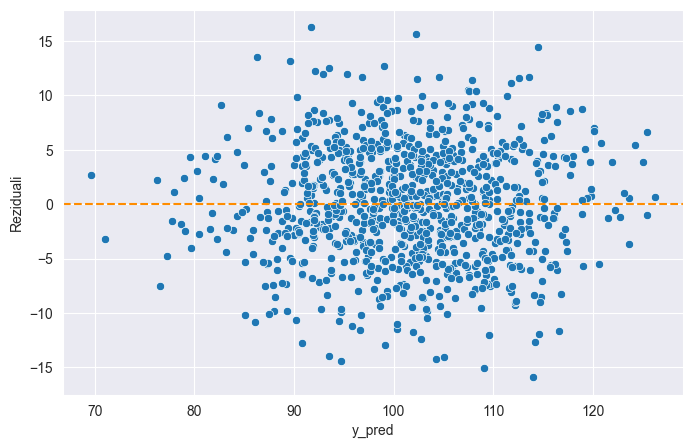

Jednaka varijansa: Test Goldfeld-Quandt daje vrednost p = 0.9689 -> Pretpostavka važi, jer se nulta hipoteza o jednakoj varijansi ne odbacuje (p >= 0.05)


In [13]:
p_value_thresh = 0.05
p_value = sm.stats.het_goldfeldquandt(df_results['Residuals'], sm.add_constant(x_train_improved))[1]

sb.scatterplot(x='Predicted', y='Residuals', data=df_results)
plt.axhline(y=0, color='darkorange', linestyle='--')
plt.ylabel('Reziduali')
plt.xlabel('y_pred')
plt.show()

if p_value >= p_value_thresh:
    print(
        f"Jednaka varijansa: Test Goldfeld-Quandt daje vrednost p = {p_value:.4f} -> "
        f"Pretpostavka važi, jer se nulta hipoteza o jednakoj varijansi ne odbacuje (p >= {p_value_thresh})"
    )
else:
    print(
        f"Jednaka varijansa: Test Goldfeld-Quandt daje vrednost p = {p_value:.4f} -> "
        f"Pretpostavka ne važi, jer se nulta hipoteza o jednakoj varijansi odbacuje (p < {p_value_thresh})"
    )

Jednaka varijana, ovde takodje imamo statisticki test koji dokazuje da predpostavka vazi. Ukoliko posmatramo grafik, predpostavka vazi kada nema sablona u rezidualima.

Racunanje adj_r2 je vec ranije zavrseno nad testnim skupom pa ga samo ispisujem da bih ispostovao format.

In [14]:
print(f"adj_r2 = {r2_adj_2:.3f}")

adj_r2 = 0.743
